# Fake News Detection
### The dataset was retrieved from kaggle

In [1]:
# first time user of nltk
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\12415\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
import pandas
news = pandas.read_csv('news.csv')

In [3]:
news['label'].value_counts()[0]

3171

In [4]:
news['label'].value_counts()[1]

3164

In [5]:
# Get dataframe information
# Represents the dimensionality of the dataframe
print('Dataframe shape: ', news.shape, '\n')
# Represents the axes of the dataframe
print('Dataframe axes: ', news.axes, '\n')
# Returns the dtypes in the dataframe
print('Dataframe dtypes: ', news.dtypes, '\n')
# Returns an int representing the number of elements in the dataframe
print('Dataframe size: ', news.size, '\n')
# Returns the first 10 rows of the dataframe
print('Dataframe head: ', '\n', news.head(10), '\n')

Dataframe shape:  (6335, 4) 

Dataframe axes:  [RangeIndex(start=0, stop=6335, step=1), Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')] 

Dataframe dtypes:  Unnamed: 0     int64
title         object
text          object
label         object
dtype: object 

Dataframe size:  25340 

Dataframe head:  
    Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   
5        6903                                        Tehran, USA   
6        7341  Girl Horrified At What She Watches Boyfriend D...   
7          95                  ‘Britain’s Schindler’ Dies at 106   
8        4869  Fact check: Trump and Clinton at the 'commande...   
9 

## Preprocessing text with NLP

In [6]:
import string
from nltk.corpus import stopwords
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

In [7]:
#Function to eliminate all the stopword
def text_process(mess):
    nopunc = [char for char in mess if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [8]:
stopwords.words('english')[0:10] # Show some stop words

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]

In [9]:
news.loc[(news['label'] == 'FAKE') , ['label']] = 1
news.loc[(news['label'] == 'REAL') , ['label']] = 0

In [10]:
tfidf_transformer = TfidfVectorizer(lowercase=True, analyzer=text_process)
reviews = tfidf_transformer.fit_transform(news['text'])
print(reviews.shape)

(6335, 128019)


In [11]:
X = reviews.toarray()
y = news['label'].astype('int')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5068, 128019) (5068,)
(1267, 128019) (1267,)


## Decision Tree Classifier

In [12]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [13]:
predictions = dtc.predict(X_test)
print('Score: ', dtc.score(X_test, y_test))

Score:  0.8303078137332282


In [14]:
print('AUC: ', metrics.roc_auc_score(y_test, dtc.predict_proba(X_test)[:,1]))

AUC:  0.8303507774836352


In [15]:
# Initialize kfold cross-validation
cv = KFold(n_splits=5, random_state=1, shuffle=True)

In [16]:
y_scores = cross_val_score(dtc, X, y, cv=cv, scoring='accuracy')
print('Cross-validated accuracy scores: ', y_scores)
print('Mean cross-validated accuracy scores: ', y_scores.mean())

y_scores_auc = cross_val_score(dtc, X, y, cv=cv, scoring='roc_auc')
print('Cross-validated auc scores: ', y_scores_auc)
print('Mean cross-validated auc scores: ', y_scores_auc.mean())

Cross-validated accuracy scores:  [0.84135754 0.8492502  0.85240726 0.82872928 0.84846093]
Mean cross-validated accuracy scores:  0.844041041831097
Cross-validated auc scores:  [0.83930317 0.85046511 0.8571865  0.83124555 0.85073261]
Mean cross-validated auc scores:  0.8457865873846503


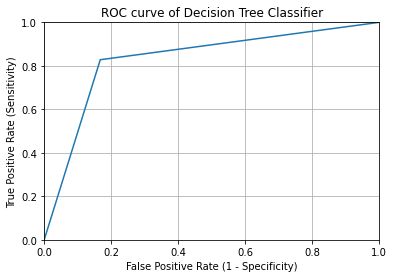

In [17]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, dtc.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve of Decision Tree Classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

## Supported Vector Machine

In [18]:
from sklearn.svm import SVC

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
SVM_model = SVC(kernel = 'rbf', C = 100, probability = True, max_iter = 500)
SVM_model.fit(X_train, y_train)

C:\Users\12415\miniconda3\envs\csc481\lib\site-packages\sklearn\svm\_base.py:255: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn('Solver terminated early (max_iter=%i).'


SVC(C=100, max_iter=500, probability=True)

In [20]:
predictions = SVM_model.predict(X_test)
print('Score: ', SVM_model.score(X_test, y_test))

Score:  0.9526440410418311


In [21]:
print('AUC: ', metrics.roc_auc_score(y_test, SVM_model.predict_proba(X_test)[:,1]))

AUC:  0.9907778409034277


In [22]:
#y_scores = cross_val_score(SVM_model, X, y, cv=5, scoring='accuracy')
#print('Cross-validated accuracy scores: ', y_scores)
#print('Mean cross-validated accuracy scores: ', y_scores.mean())

#y_scores_auc = cross_val_score(SVM_model, X, y, cv=5, scoring='roc_auc')
#print('Cross-validated auc scores: ', y_scores_auc)
#print('Mean cross-validated auc scores: ', y_scores_auc.mean())

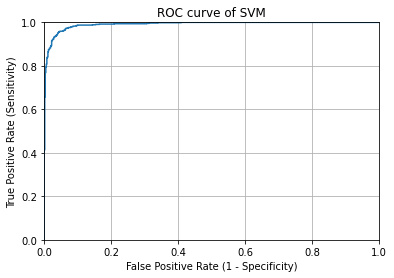

In [23]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, SVM_model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve of SVM')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)

## Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [25]:
predictions = log_model.predict(X_test)
print('Score: ', log_model.score(X_test, y_test))

Score:  0.925808997632202


In [26]:
print('AUC: ', metrics.roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1]))

AUC:  0.9801901743264659


In [27]:
y_scores_log = cross_val_score(log_model, X, y, cv=cv, scoring='accuracy')
print('Cross-validated accuracy scores: ', y_scores_log)
print('Mean cross-validated accuracy scores: ', y_scores_log.mean())

y_scores_log_auc = cross_val_score(log_model, X, y, cv=cv, scoring='roc_auc')
print('Cross-validated auc scores: ', y_scores_log_auc)
print('Mean cross-validated auc scores: ', y_scores_log_auc.mean())

Cross-validated accuracy scores:  [0.93212313 0.91791634 0.91633781 0.93449092 0.91475927]
Mean cross-validated accuracy scores:  0.9231254932912393
Cross-validated auc scores:  [0.98394079 0.9821213  0.97749217 0.98447304 0.97851081]
Mean cross-validated auc scores:  0.9813076223180394


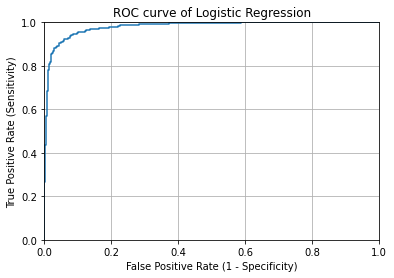

In [28]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, log_model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC curve of Logistic Regression')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.grid(True)